In [26]:
import xarray as xr
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy
from matplotlib import cm
import cartopy.feature as cfeature
import matplotlib.ticker as mticker
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER

## Setup & Dependencies

# UTC vs Solar Day Maximum Temperature Analysis

## Overview
This notebook compares two methods of computing daily maximum temperatures from ERA5 climate data:

1. **UTC Method**: Daily maximum computed using UTC time with a 3-hour offset (ERA5 timestamp convention)
2. **Solar Day Method**: Daily maximum computed using solar local day timing

## Objective
Understand how different timestamp conventions affect daily maximum temperature calculations and identify spatial/temporal differences across US cities.

## Data
- ERA5 climate data for 1941
- Focus locations: Fairbanks, Denver, San Francisco, Chicago, NYC
- Analysis includes global maps, city-level time series, and seasonal breakdowns

## Data Loading & Preprocessing

In [27]:
tmaxUTC = xr.open_dataset("/Projects/RAPrototype/ERA5/UTCTime/tmax.2m.1941.UTC.nc")
tmaxUTC['lon'] = (tmaxUTC['lon'] + 180) % 360 - 180                                                                                                           
tmaxUTC = tmaxUTC.sortby(tmaxUTC.lon)
tmaxSLD = xr.open_dataset("/Projects/RAPrototype/ERA5/SolarDayTime/tmax.2m.1941.FromSolarDayTime.nc")
tmaxSLD['lon'] = (tmaxSLD['lon'] + 180) % 360 - 180                                                                                                           
tmaxSLD = tmaxSLD.sortby(tmaxSLD.lon)
tmaxSLD['time'] = tmaxUTC['time']

## City Selection & Setup

In [28]:
FairbanksUTC = tmaxUTC['tmax'].sel(lat=64.8, lon=-147.8, method='nearest')
DenverUTC = tmaxUTC['tmax'].sel(lat=39.7, lon=-105.0, method='nearest')
SanFranciscoUTC = tmaxUTC['tmax'].sel(lat=37.8, lon=-122.4, method='nearest')
ChicagoUTC = tmaxUTC['tmax'].sel(lat=41.8, lon=-87.6, method='nearest')
NYCUTC = tmaxUTC['tmax'].sel(lat=40.7, lon=-74.0, method='nearest')


FairbanksSLD = tmaxSLD['tmax'].sel(lat=64.8, lon=-147.8, method='nearest')
DenverSLD = tmaxSLD['tmax'].sel(lat=39.7, lon=-105.0, method='nearest')
SanFranciscoSLD = tmaxSLD['tmax'].sel(lat=37.8, lon=-122.4, method='nearest')
ChicagoSLD = tmaxSLD['tmax'].sel(lat=41.8, lon=-87.6, method='nearest')
NYCSLD = tmaxSLD['tmax'].sel(lat=40.7, lon=-74.0, method='nearest')

In [29]:
UTC = [FairbanksUTC, DenverUTC, SanFranciscoUTC, ChicagoUTC, NYCUTC]
SLD = [FairbanksSLD, DenverSLD, SanFranciscoSLD, ChicagoSLD, NYCSLD]
tip = ['Fairbanks', 'Denver', 'SanFrancisco', 'Chicago', 'NYC' ]

/tmp/ipykernel_3000294/1329674429.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('turbo')


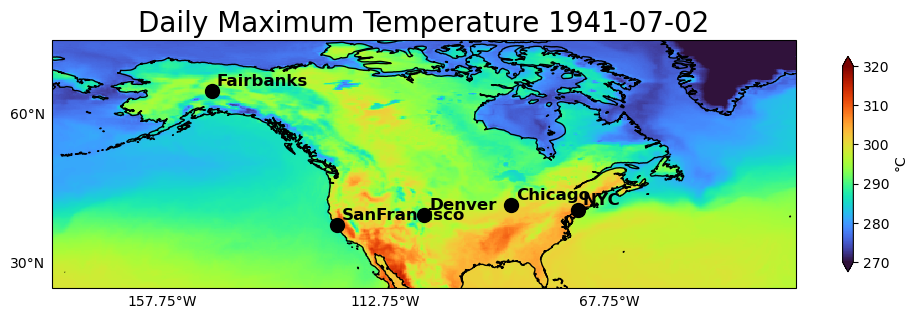

In [30]:
cmap = cm.get_cmap('turbo')
proj=ccrs.PlateCarree(central_longitude=0)

fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(12,8),subplot_kw={'projection':proj})
tmaxUTC['tmax'].isel(time=182).plot.pcolormesh(ax=ax,cmap=cmap,transform=proj,cbar_kwargs={'label':'$\degree$C','shrink':0.35},vmin=270,vmax=320) 
for i in range(len(tip)):
    ax.plot(UTC[i]['lon'], UTC[i]['lat'], marker='o', color='black', markersize=10, transform=proj)
    ax.text(UTC[i]['lon']+1, UTC[i]['lat']+1, tip[i], fontsize=12, fontweight='bold', color='black', transform=proj)
gl1 = ax.gridlines(draw_labels={"bottom": "x", "left": "y"},  color='gray', alpha=0.001, linestyle='--')
ax.add_feature(cfeature.COASTLINE,edgecolor='black',facecolor='none',zorder=1)
ax.set_extent([-180, -30, 25, 75], crs=ccrs.PlateCarree())
ax.set_title('UTC',fontsize=20)
custom_xticks = [0-180, 22.25-180, 67.25-180,112.25-180,157.25-180, 180-180, 202.25-180,247.25-180,292.25-180,337.25-180,360-180]
custom_yticks = [-60, -30, 0, 30, 60]

# 3. Apply the locators to the gridliner

gl1.xlocator = mticker.FixedLocator(custom_xticks)
gl1.ylocator = mticker.FixedLocator(custom_yticks)

# 4. Apply standard formatters
gl1.xformatter = LONGITUDE_FORMATTER
gl1.yformatter = LATITUDE_FORMATTER
plt.title(f"Daily Maximum Temperature {tmaxUTC['time'][182].dt.strftime('%Y-%m-%d').data}",fontsize=20)
plt.show()

# Part 1: Global & Local Analysis

## Global Temperature Map

In [31]:
CB_color = ['#377eb8', '#ff7f00', '#4daf4a',\
            '#e41a1c', '#a65628', '#984ea3',\
            '#999999', '#f781bf', '#dede00']

## City Time Series - Full Year

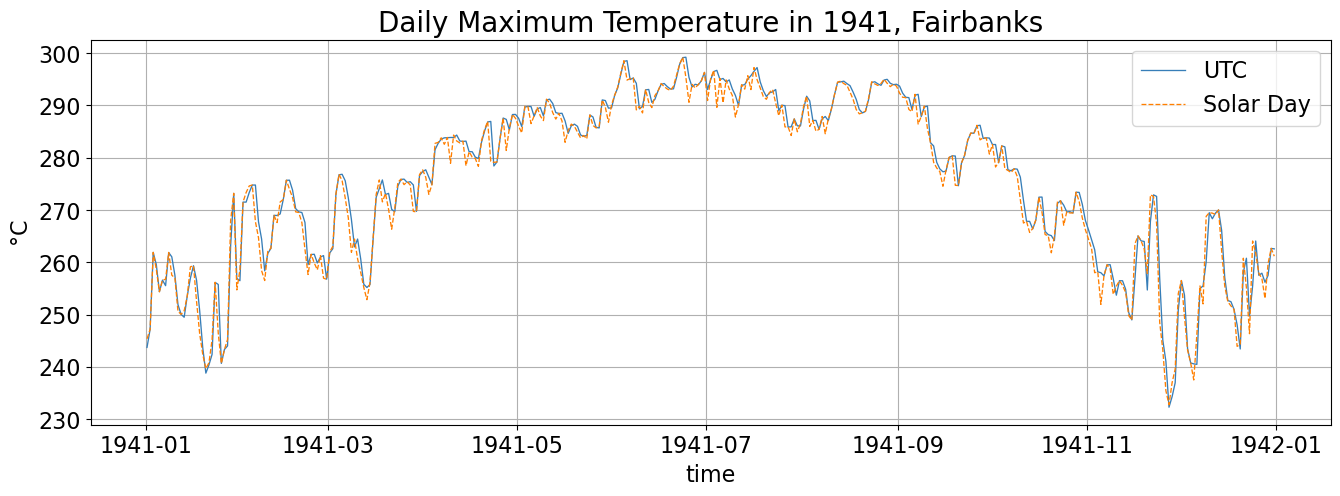

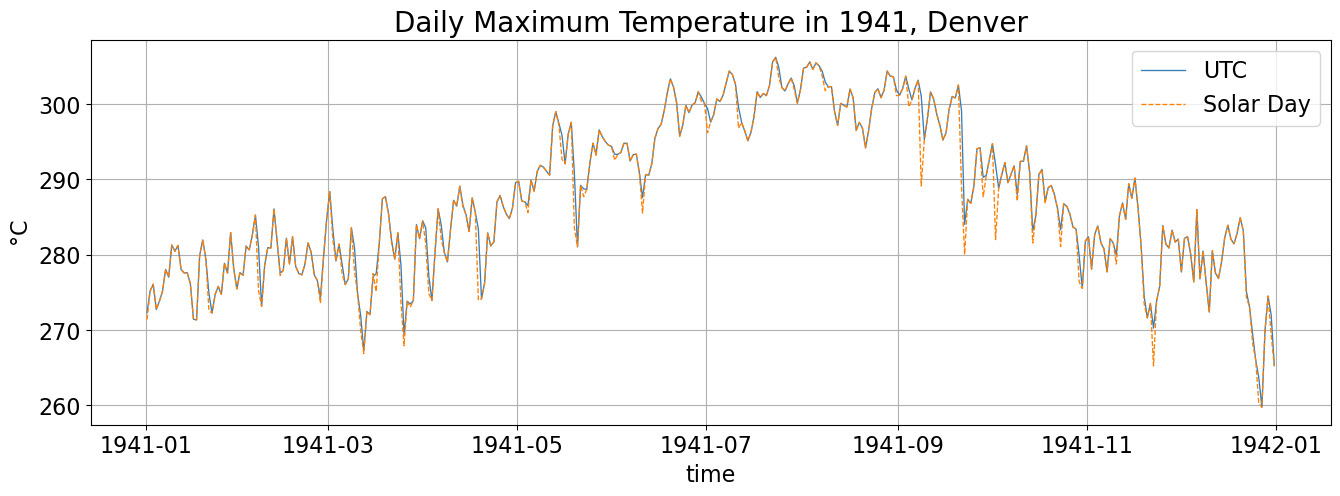

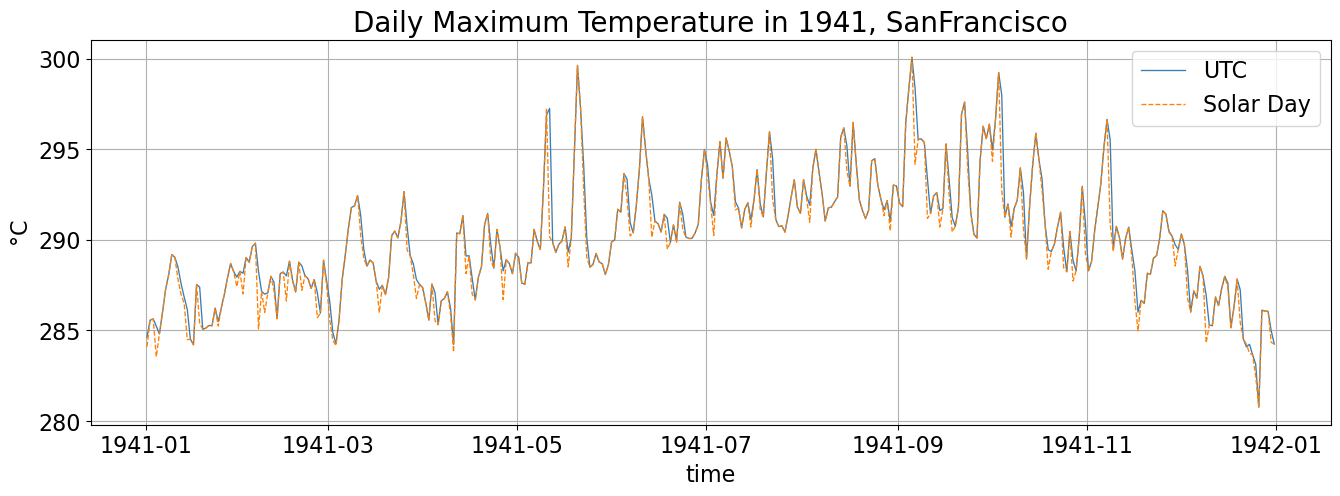

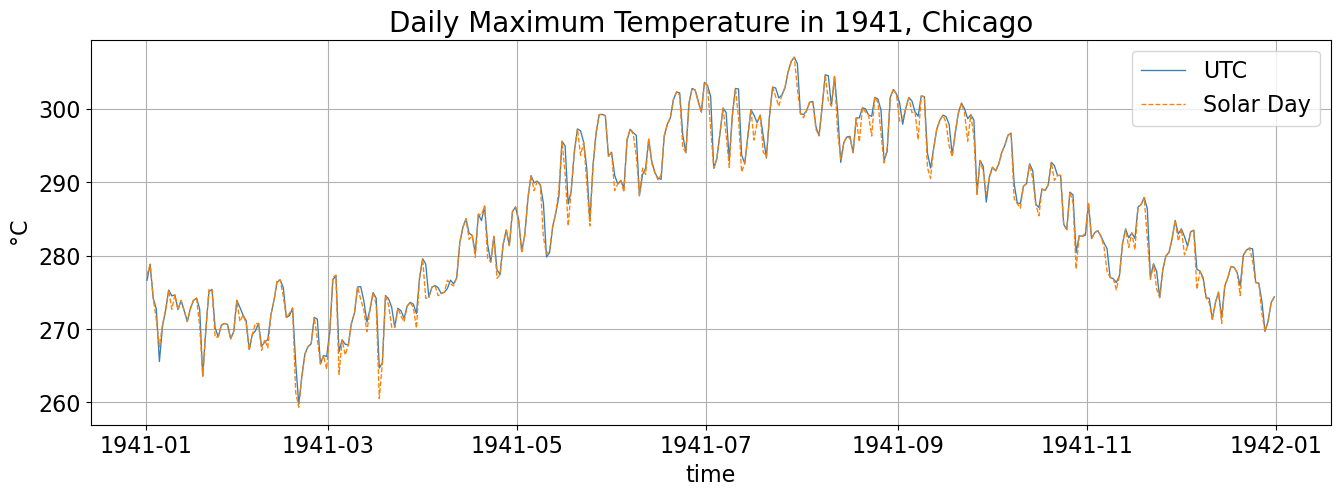

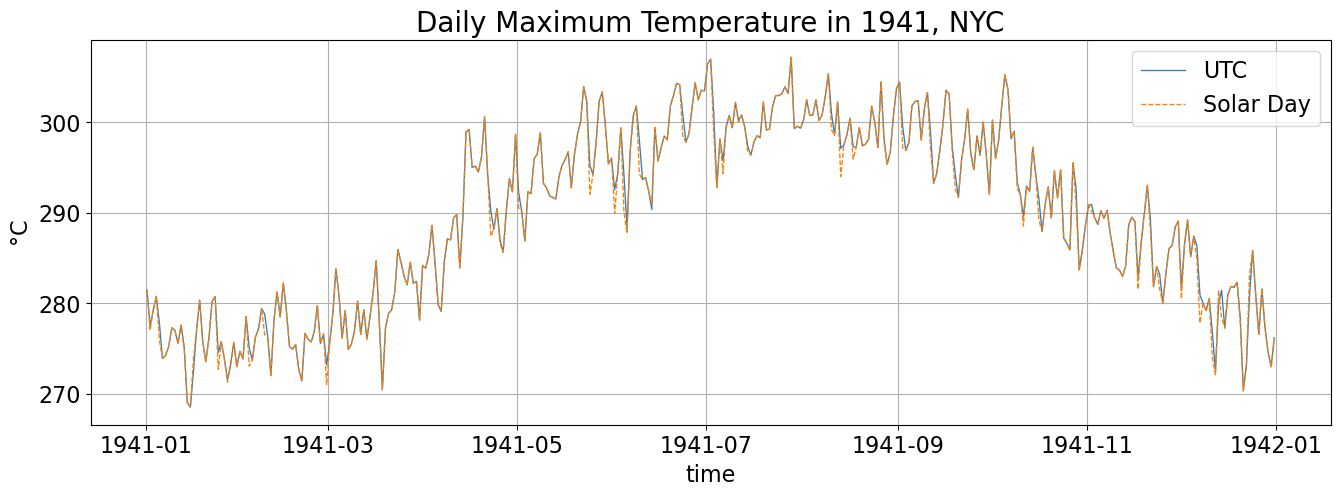

In [32]:
for ip in range(len(UTC)):

  fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(16,5))
  ax.plot(tmaxUTC['time'],UTC[ip],color=CB_color[0],linewidth=0.95,label='UTC')
  ax.plot(tmaxSLD['time'],SLD[ip],color=CB_color[1],linewidth=0.95,linestyle='--',label='Solar Day')
  ax.tick_params(labelsize=16)
  plt.legend(loc='best',prop={'size': 16})
  plt.grid(True)
  plt.ylabel(f'$\degree$C',fontsize=16)  
  plt.xlabel('time',fontsize=16)
  plt.title(f'Daily Maximum Temperature in {tmaxUTC["time"].dt.strftime("%Y")[0].data}, {tip[ip]}',fontsize=20)
  plt.show()

# Part 2: Seasonal Analysis

## Summer Period Analysis

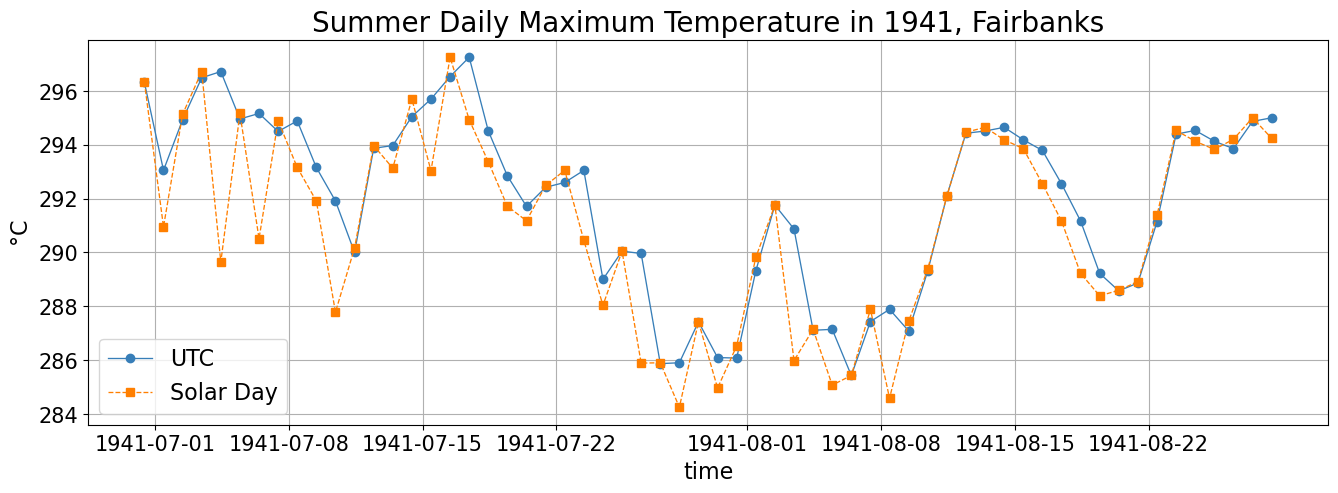

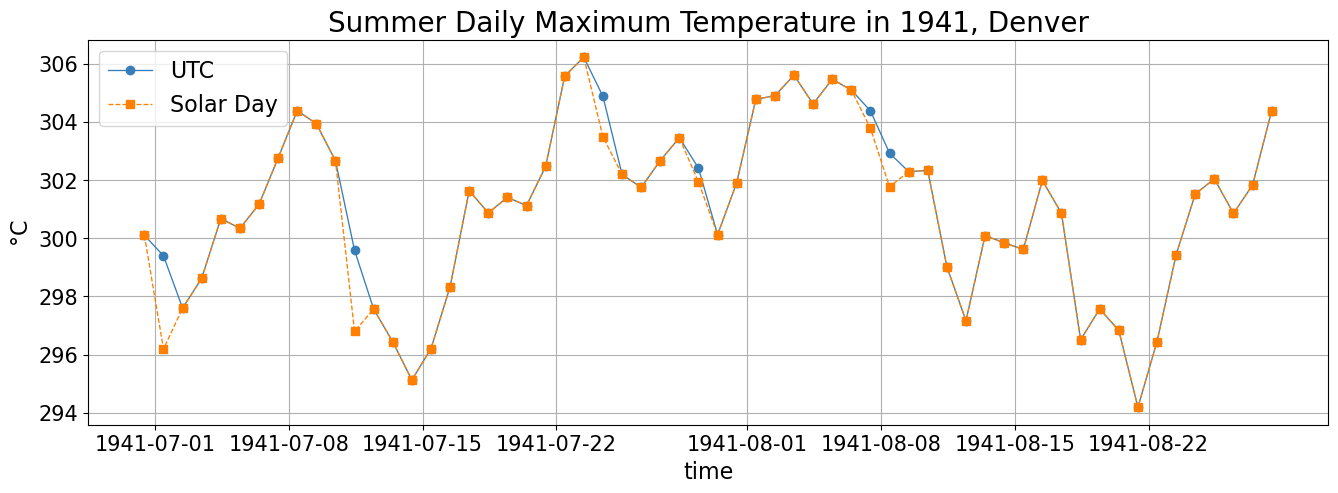

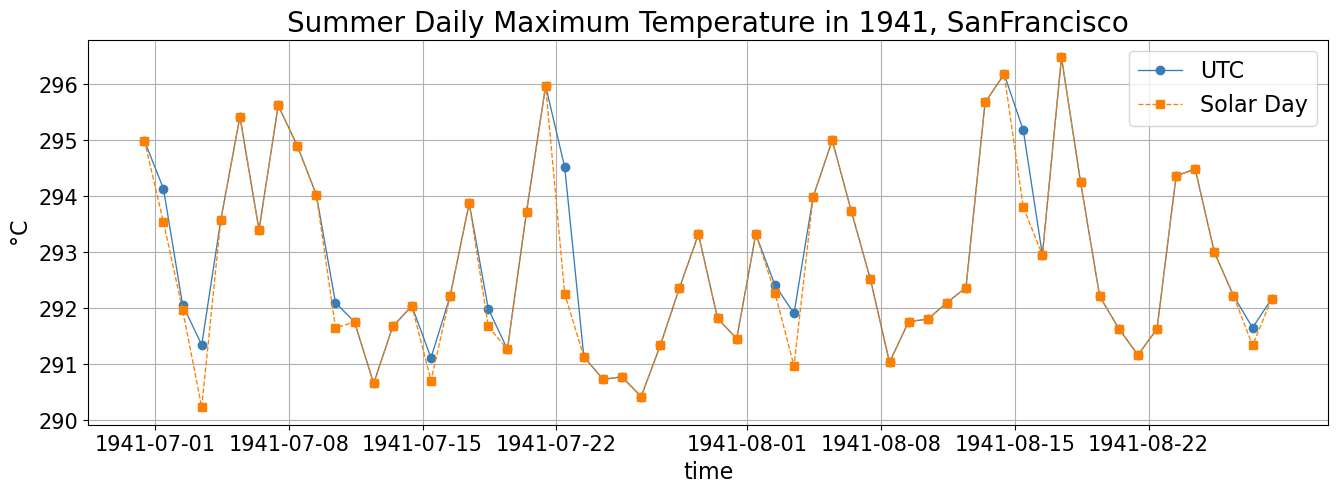

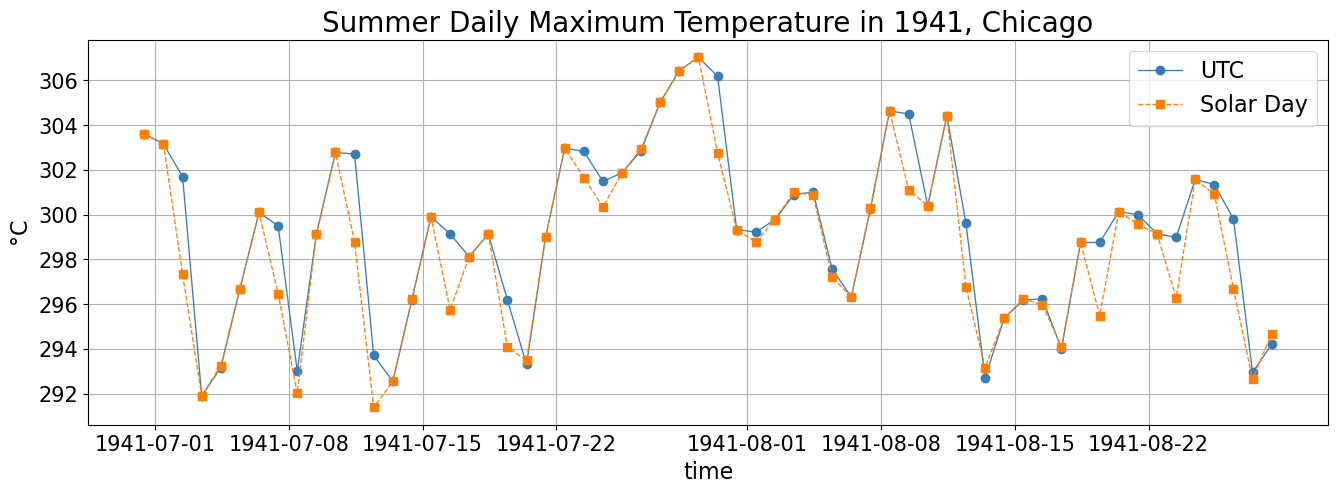

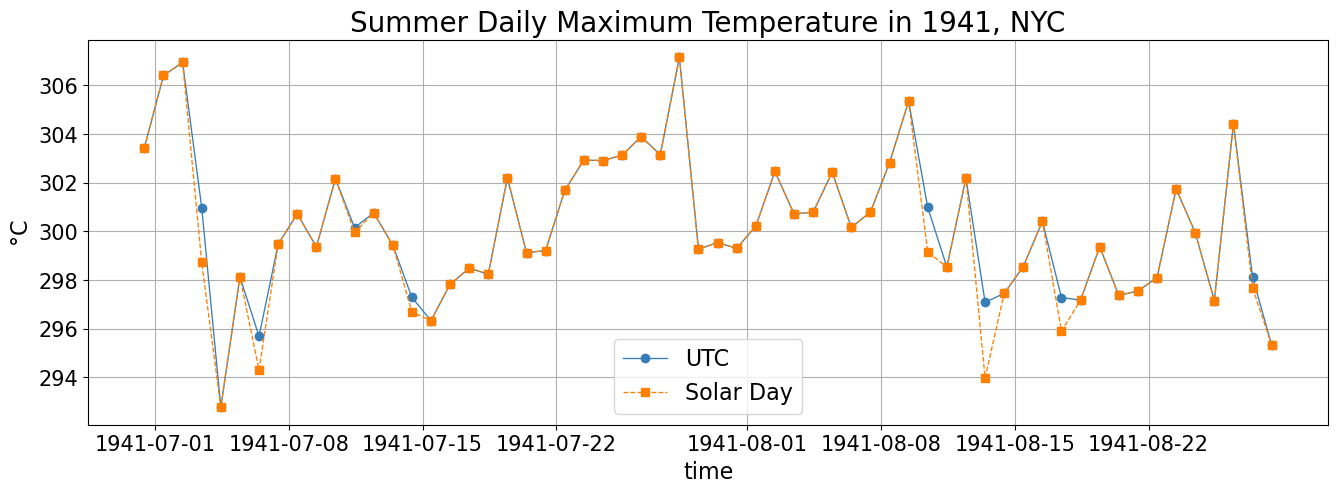

In [33]:
for ip in range(len(UTC)):

  fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(16,5))
  ax.plot(tmaxUTC['time'].isel(time=slice(180,240)),UTC[ip].isel(time=slice(180,240)),marker='o',color=CB_color[0],linewidth=0.95,label='UTC')
  ax.plot(tmaxSLD['time'].isel(time=slice(180,240)),SLD[ip].isel(time=slice(180,240)),marker='s',color=CB_color[1],linewidth=0.95,linestyle='--',label='Solar Day')
  ax.tick_params(labelsize=15)
  plt.legend(loc='best',prop={'size': 16})
  plt.grid(True)
  plt.ylabel(f'$\degree$C',fontsize=16)  
  plt.xlabel('time',fontsize=16)
  plt.title(f'Summer Daily Maximum Temperature in {tmaxUTC["time"].dt.strftime("%Y")[0].data}, {tip[ip]}',fontsize=20)
  plt.show()

## Winter Period Analysis

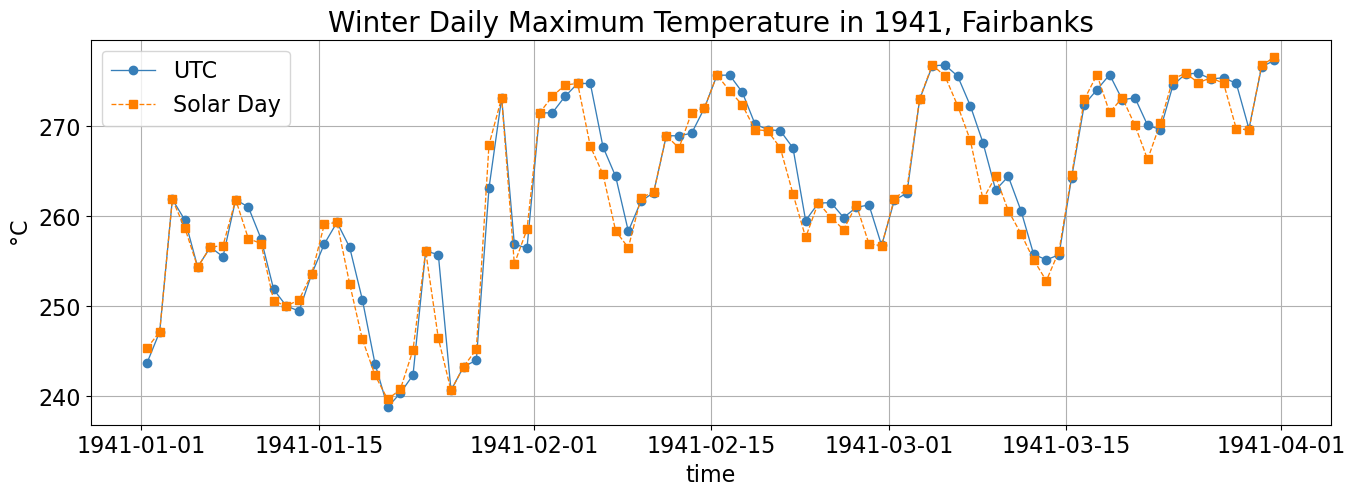

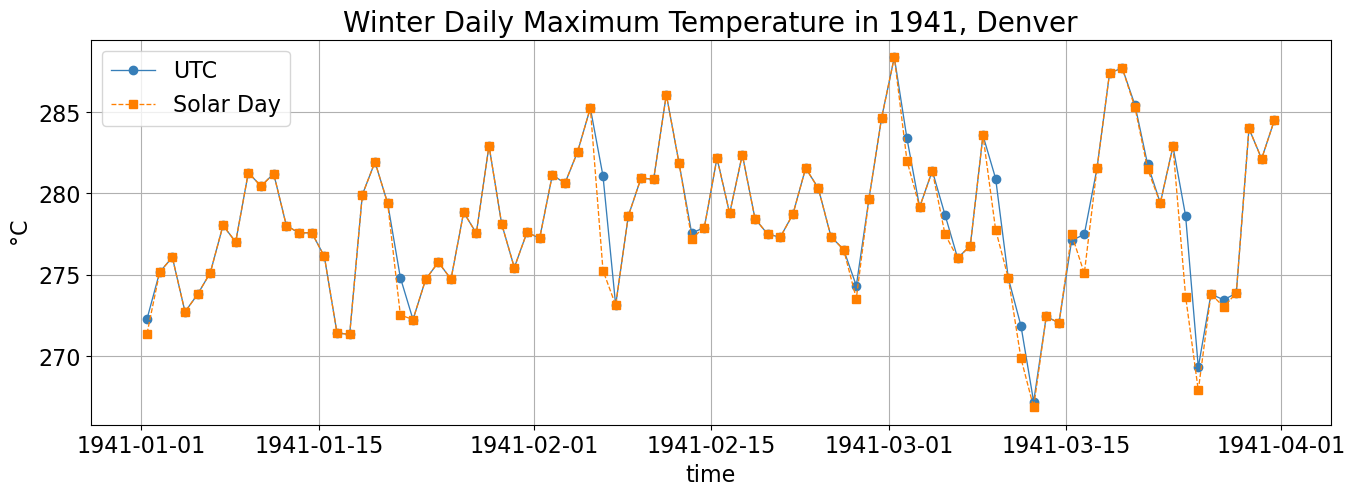

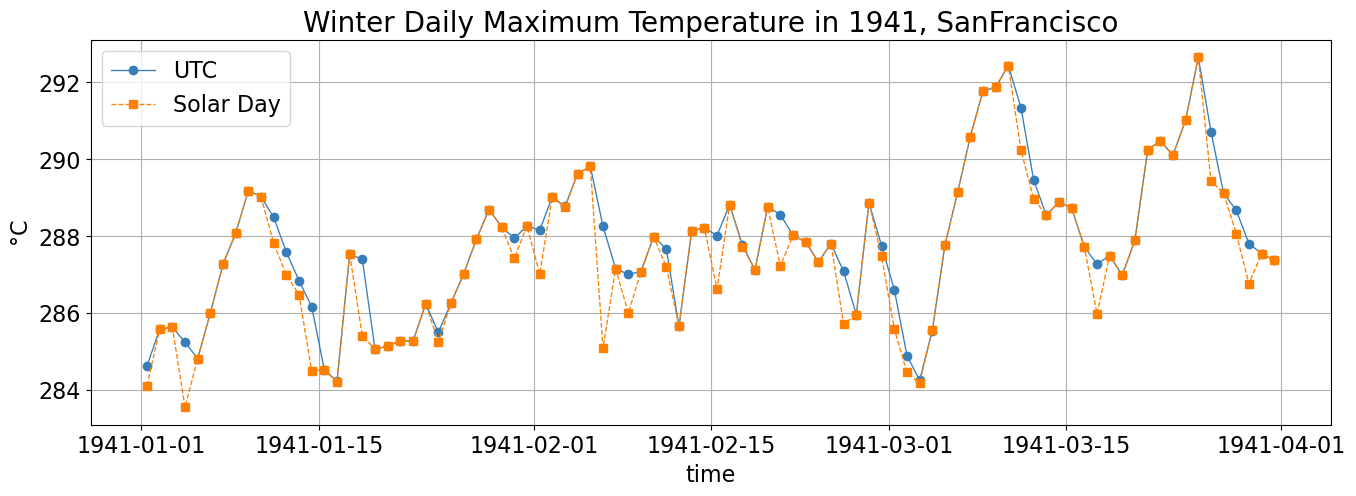

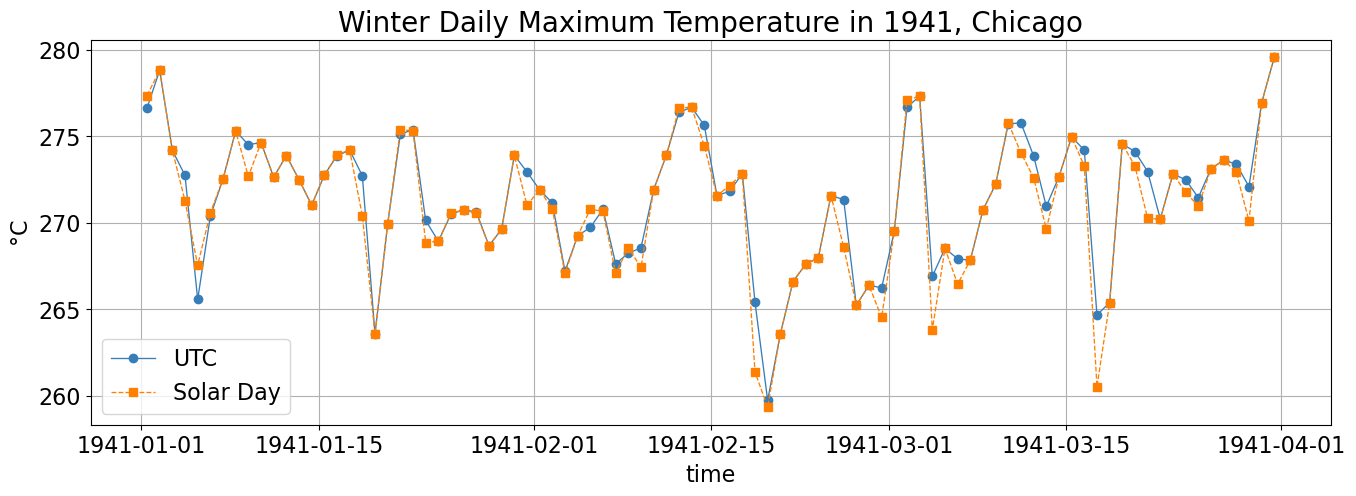

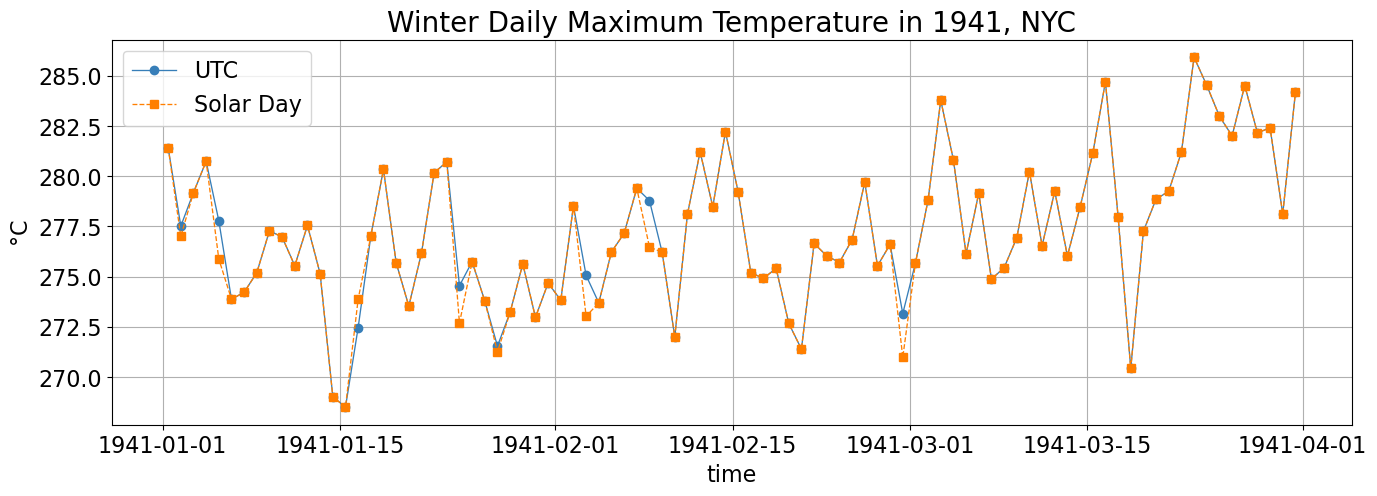

In [34]:
for ip in range(len(UTC)):

  fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(16,5))
  ax.plot(tmaxUTC['time'].isel(time=slice(0,90)),UTC[ip].isel(time=slice(0,90)),marker='o',color=CB_color[0],linewidth=0.95,label='UTC')
  ax.plot(tmaxSLD['time'].isel(time=slice(0,90)),SLD[ip].isel(time=slice(0,90)),marker='s',color=CB_color[1],linewidth=0.95,linestyle='--',label='Solar Day')
  ax.tick_params(labelsize=16)
  plt.legend(loc='best',prop={'size': 16})
  plt.grid(True)
  plt.ylabel(f'$\degree$C',fontsize=16)  
  plt.xlabel('time',fontsize=16)
  plt.title(f'Winter Daily Maximum Temperature in {tmaxUTC["time"].dt.strftime("%Y")[0].data}, {tip[ip]}',fontsize=20)
  plt.show()

In [35]:
state_borders =\
cartopy.feature.NaturalEarthFeature(category='cultural',\
        name='admin_1_states_provinces_lakes', scale='50m', facecolor='none')

# Part 3: Regional Deep Dives

/tmp/ipykernel_3000294/188399294.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('turbo')


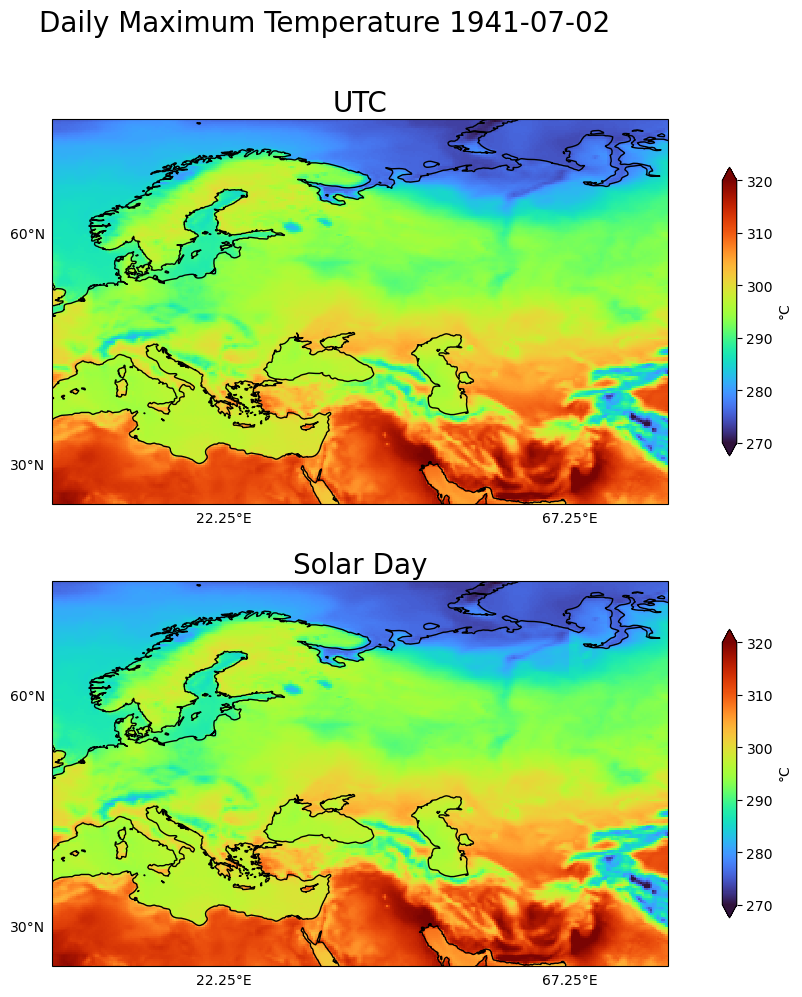

In [36]:
cmap = cm.get_cmap('turbo')
proj=ccrs.PlateCarree(central_longitude=0)

fig, ax = plt.subplots(nrows=2,ncols=1,figsize=(14,11),subplot_kw={'projection':proj})
tmaxUTC['tmax'].isel(time=182).plot.pcolormesh(ax=ax[0],cmap=cmap,transform=proj,cbar_kwargs={'label':'$\degree$C','shrink':0.75},vmin=270,vmax=320) 
tmaxSLD['tmax'].isel(time=182).plot.pcolormesh(ax=ax[1],cmap=cmap,transform=proj,cbar_kwargs={'label':'$\degree$C','shrink':0.75},vmin=270,vmax=320)
gl0 = ax[0].gridlines(draw_labels={"bottom": "x", "left": "y"},  color='gray', alpha=0.001, linestyle='--')
gl1 = ax[1].gridlines(draw_labels={"bottom": "x", "left": "y"},  color='gray', alpha=0.001, linestyle='--')
ax[0].add_feature(cfeature.COASTLINE,edgecolor='black',facecolor='none',zorder=1)
ax[1].add_feature(cfeature.COASTLINE,edgecolor='black',facecolor='none',zorder=1)
ax[0].set_extent([0, 80, 25, 75], crs=ccrs.PlateCarree())
ax[1].set_extent([0, 80, 25, 75], crs=ccrs.PlateCarree())
ax[0].set_title('UTC',fontsize=20)
ax[1].set_title('Solar Day',fontsize=20)
custom_xticks = [0, 22.25, 67.25,112.25,157.25, 180, 202.25,247.25,292.25,337.25,360]
custom_yticks = [-60, -30, 0, 30, 60]

# 3. Apply the locators to the gridliner
gl0.xlocator = mticker.FixedLocator(custom_xticks)
gl0.ylocator = mticker.FixedLocator(custom_yticks)
gl1.xlocator = mticker.FixedLocator(custom_xticks)
gl1.ylocator = mticker.FixedLocator(custom_yticks)

# 4. Apply standard formatters
gl0.xformatter = LONGITUDE_FORMATTER
gl0.yformatter = LATITUDE_FORMATTER
gl1.xformatter = LONGITUDE_FORMATTER
gl1.yformatter = LATITUDE_FORMATTER
plt.suptitle(f"Daily Maximum Temperature {tmaxUTC['time'][182].dt.strftime('%Y-%m-%d').data}",fontsize=20)
plt.show()

## UTC vs Solar Day Comparison Maps - Summer Solstice

/tmp/ipykernel_3000294/924735740.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('turbo')


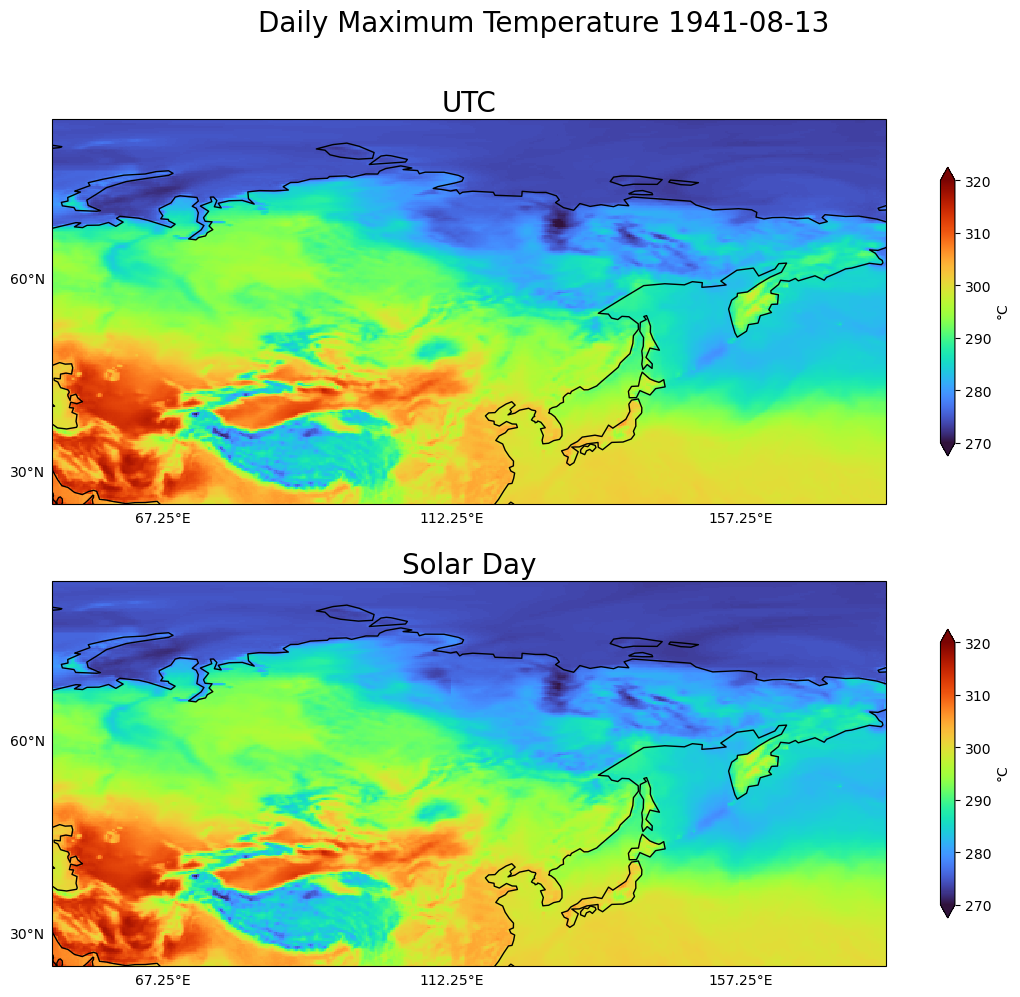

In [37]:
cmap = cm.get_cmap('turbo')
proj=ccrs.PlateCarree(central_longitude=0)

fig, ax = plt.subplots(nrows=2,ncols=1,figsize=(14,11),subplot_kw={'projection':proj})
tmaxUTC['tmax'].isel(time=224).plot.pcolormesh(ax=ax[0],cmap=cmap,transform=proj,cbar_kwargs={'label':'$\degree$C','shrink':0.75},vmin=270,vmax=320) 
tmaxSLD['tmax'].isel(time=224).plot.pcolormesh(ax=ax[1],cmap=cmap,transform=proj,cbar_kwargs={'label':'$\degree$C','shrink':0.75},vmin=270,vmax=320)
gl0 = ax[0].gridlines(draw_labels={"bottom": "x", "left": "y"},  color='gray', alpha=0.001, linestyle='--')
gl1 = ax[1].gridlines(draw_labels={"bottom": "x", "left": "y"},  color='gray', alpha=0.001, linestyle='--')
ax[0].add_feature(cfeature.COASTLINE,edgecolor='black',facecolor='none',zorder=1)
ax[1].add_feature(cfeature.COASTLINE,edgecolor='black',facecolor='none',zorder=1)
ax[0].set_extent([50, 180, 25, 85], crs=ccrs.PlateCarree())
ax[1].set_extent([50, 180, 25, 85], crs=ccrs.PlateCarree())
ax[0].set_title('UTC',fontsize=20)
ax[1].set_title('Solar Day',fontsize=20)
custom_xticks = [0, 22.25, 67.25,112.25,157.25, 180, 202.25,247.25,292.25,337.25,360]
custom_yticks = [-60, -30, 0, 30, 60]

# 3. Apply the locators to the gridliner
gl0.xlocator = mticker.FixedLocator(custom_xticks)
gl0.ylocator = mticker.FixedLocator(custom_yticks)
gl1.xlocator = mticker.FixedLocator(custom_xticks)
gl1.ylocator = mticker.FixedLocator(custom_yticks)

# 4. Apply standard formatters
gl0.xformatter = LONGITUDE_FORMATTER
gl0.yformatter = LATITUDE_FORMATTER
gl1.xformatter = LONGITUDE_FORMATTER
gl1.yformatter = LATITUDE_FORMATTER
plt.suptitle(f"Daily Maximum Temperature {tmaxUTC['time'][224].dt.strftime('%Y-%m-%d').data}",fontsize=20)
plt.show()

## UTC vs Solar Day Comparison Maps - Autumn Equinox

/tmp/ipykernel_3000294/2020615587.py:1: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  cmap = cm.get_cmap('turbo')


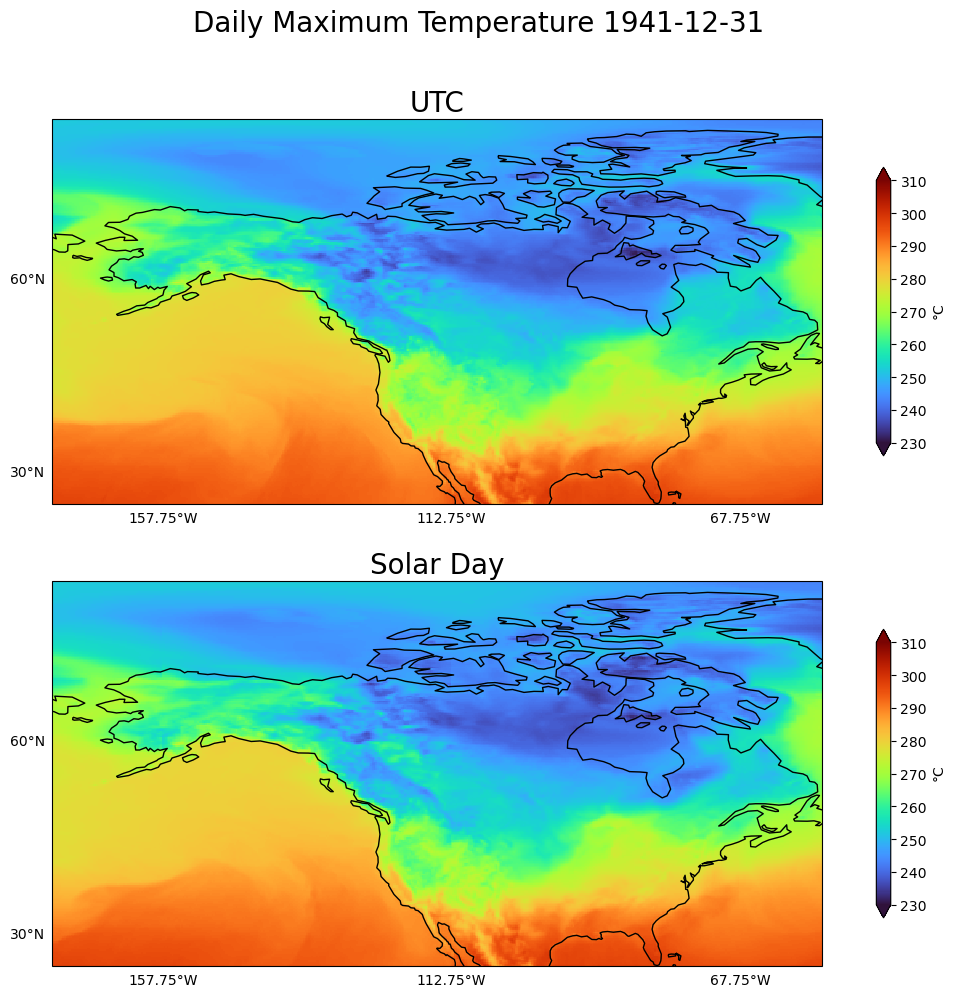

In [38]:
cmap = cm.get_cmap('turbo')
proj=ccrs.PlateCarree(central_longitude=0)

fig, ax = plt.subplots(nrows=2,ncols=1,figsize=(14,11),subplot_kw={'projection':proj})
tmaxUTC['tmax'].isel(time=364).plot.pcolormesh(ax=ax[0],cmap=cmap,transform=proj,cbar_kwargs={'label':'$\degree$C','shrink':0.75},vmin=230,vmax=310) 
tmaxSLD['tmax'].isel(time=364).plot.pcolormesh(ax=ax[1],cmap=cmap,transform=proj,cbar_kwargs={'label':'$\degree$C','shrink':0.75},vmin=230,vmax=310)
gl0 = ax[0].gridlines(draw_labels={"bottom": "x", "left": "y"},  color='gray', alpha=0.001, linestyle='--')
gl1 = ax[1].gridlines(draw_labels={"bottom": "x", "left": "y"},  color='gray', alpha=0.001, linestyle='--')
ax[0].add_feature(cfeature.COASTLINE,edgecolor='black',facecolor='none',zorder=1)
ax[1].add_feature(cfeature.COASTLINE,edgecolor='black',facecolor='none',zorder=1)
ax[0].set_extent([185, 305, 25, 85], crs=ccrs.PlateCarree())
ax[1].set_extent([185, 305, 25, 85], crs=ccrs.PlateCarree())
ax[0].set_title('UTC',fontsize=20)
ax[1].set_title('Solar Day',fontsize=20)
custom_xticks = [202.25-360,247.25-360,292.25-360,337.25-360,360-360]
custom_yticks = [-60, -30, 0, 30, 60]

# 3. Apply the locators to the gridliner
gl0.xlocator = mticker.FixedLocator(custom_xticks)
gl0.ylocator = mticker.FixedLocator(custom_yticks)
gl1.xlocator = mticker.FixedLocator(custom_xticks)
gl1.ylocator = mticker.FixedLocator(custom_yticks)

# 4. Apply standard formatters
gl0.xformatter = LONGITUDE_FORMATTER
gl0.yformatter = LATITUDE_FORMATTER
gl1.xformatter = LONGITUDE_FORMATTER
gl1.yformatter = LATITUDE_FORMATTER
plt.suptitle(f"Daily Maximum Temperature {tmaxUTC['time'][364].dt.strftime('%Y-%m-%d').data}",fontsize=20)
plt.show()

## UTC vs Solar Day Comparison Maps - Winter Solstice

No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


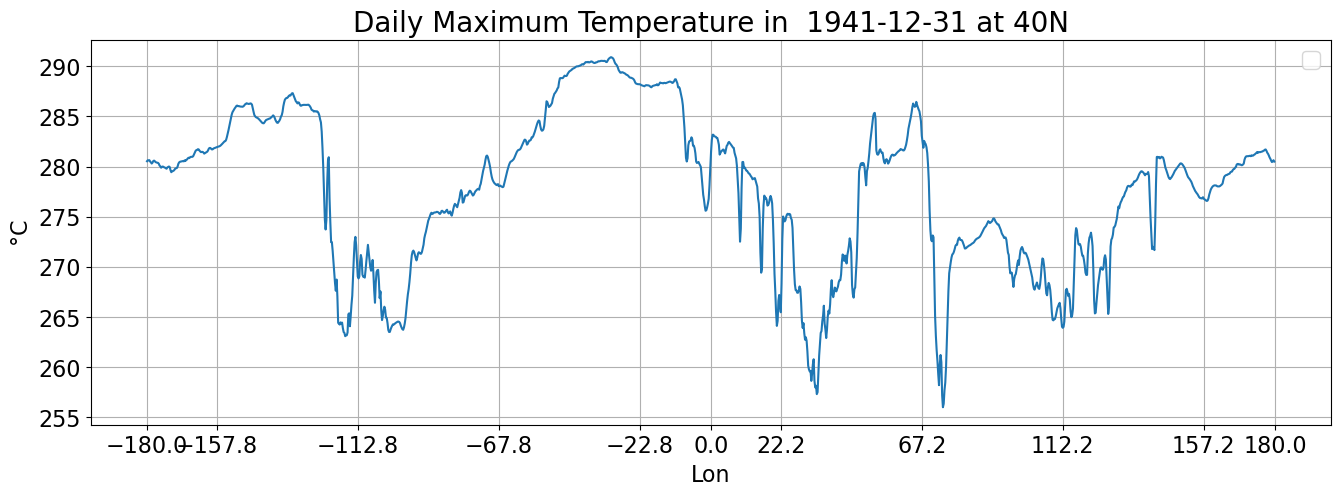

In [39]:

fig, ax = plt.subplots(nrows=1,ncols=1,figsize=(16,5))
tmaxSLD['tmax'].isel(time=364).sel(lat=40).plot()
ax.tick_params(labelsize=16)
plt.legend(loc='best',prop={'size': 16})
plt.grid(True)
plt.ylabel(f'$\degree$C',fontsize=16)  
plt.xlabel('Lon',fontsize=16)
plt.xticks([0-180, 22.25-180, 67.25-180,112.25-180,157.25-180, 180-180, 202.25-180,247.25-180,292.25-180,337.25-180,360-180])
plt.title(f"Daily Maximum Temperature in  {tmaxUTC['time'][364].dt.strftime('%Y-%m-%d').data} at 40N",fontsize=20)
plt.show()

## Latitude Cross-Section at 40°N

# Part 4: Time Convention Analysis

## Understanding ERA5 Timestamp Conventions

This section explores how ERA5 timestamps differ from solar local time conventions and demonstrates the time offset calculations used in the analysis.

### GMT 0 Time

In [40]:
ds=xr.open_dataset("/Projects/era5/monolevel/tmax.2m.1960.nc")
ds['time'].data[0:24]

array(['1960-01-01T00:00:00.000000000', '1960-01-01T03:00:00.000000000',
       '1960-01-01T06:00:00.000000000', '1960-01-01T09:00:00.000000000',
       '1960-01-01T12:00:00.000000000', '1960-01-01T15:00:00.000000000',
       '1960-01-01T18:00:00.000000000', '1960-01-01T21:00:00.000000000',
       '1960-01-02T00:00:00.000000000', '1960-01-02T03:00:00.000000000',
       '1960-01-02T06:00:00.000000000', '1960-01-02T09:00:00.000000000',
       '1960-01-02T12:00:00.000000000', '1960-01-02T15:00:00.000000000',
       '1960-01-02T18:00:00.000000000', '1960-01-02T21:00:00.000000000',
       '1960-01-03T00:00:00.000000000', '1960-01-03T03:00:00.000000000',
       '1960-01-03T06:00:00.000000000', '1960-01-03T09:00:00.000000000',
       '1960-01-03T12:00:00.000000000', '1960-01-03T15:00:00.000000000',
       '1960-01-03T18:00:00.000000000', '1960-01-03T21:00:00.000000000'],
      dtype='datetime64[ns]')

### Local Time Offset - Denver (GMT -6)

In [41]:
(ds['time'] + np.timedelta64(-6, 'h')).data[0:24]

array(['1959-12-31T18:00:00.000000000', '1959-12-31T21:00:00.000000000',
       '1960-01-01T00:00:00.000000000', '1960-01-01T03:00:00.000000000',
       '1960-01-01T06:00:00.000000000', '1960-01-01T09:00:00.000000000',
       '1960-01-01T12:00:00.000000000', '1960-01-01T15:00:00.000000000',
       '1960-01-01T18:00:00.000000000', '1960-01-01T21:00:00.000000000',
       '1960-01-02T00:00:00.000000000', '1960-01-02T03:00:00.000000000',
       '1960-01-02T06:00:00.000000000', '1960-01-02T09:00:00.000000000',
       '1960-01-02T12:00:00.000000000', '1960-01-02T15:00:00.000000000',
       '1960-01-02T18:00:00.000000000', '1960-01-02T21:00:00.000000000',
       '1960-01-03T00:00:00.000000000', '1960-01-03T03:00:00.000000000',
       '1960-01-03T06:00:00.000000000', '1960-01-03T09:00:00.000000000',
       '1960-01-03T12:00:00.000000000', '1960-01-03T15:00:00.000000000'],
      dtype='datetime64[ns]')

### Combined Offset - Denver (GMT -6) + ERA5 Offset (-3H)

In [42]:
(ds['time'] + np.timedelta64(-3, 'h')+ np.timedelta64(-6, 'h')).data[0:24]

array(['1959-12-31T15:00:00.000000000', '1959-12-31T18:00:00.000000000',
       '1959-12-31T21:00:00.000000000', '1960-01-01T00:00:00.000000000',
       '1960-01-01T03:00:00.000000000', '1960-01-01T06:00:00.000000000',
       '1960-01-01T09:00:00.000000000', '1960-01-01T12:00:00.000000000',
       '1960-01-01T15:00:00.000000000', '1960-01-01T18:00:00.000000000',
       '1960-01-01T21:00:00.000000000', '1960-01-02T00:00:00.000000000',
       '1960-01-02T03:00:00.000000000', '1960-01-02T06:00:00.000000000',
       '1960-01-02T09:00:00.000000000', '1960-01-02T12:00:00.000000000',
       '1960-01-02T15:00:00.000000000', '1960-01-02T18:00:00.000000000',
       '1960-01-02T21:00:00.000000000', '1960-01-03T00:00:00.000000000',
       '1960-01-03T03:00:00.000000000', '1960-01-03T06:00:00.000000000',
       '1960-01-03T09:00:00.000000000', '1960-01-03T12:00:00.000000000'],
      dtype='datetime64[ns]')

In [43]:
from datetime import datetime
import pytz

### Working with Timezones and Datetime Offsets

In [44]:
print(np.datetime64(datetime(2026, 1, 1, 0, 0, 0)), 'ns')
print(np.datetime64(datetime(2026, 1, 1, 0, 0, 0))+ np.timedelta64(3, 'h'), 'ns')

2026-01-01T00:00:00.000000 ns
2026-01-01T03:00:00.000000 ns


In [45]:
time0 = datetime.now(pytz.timezone('Etc/GMT+0'))
timem6 = np.datetime64(time0, 'ns') + np.timedelta64(-6, 'h')
print(np.datetime64(time0, 'ns'))
print(timem6)

2026-06-29T20:25:31.658333000
2026-06-29T14:25:31.658333000


/tmp/ipykernel_3000294/1506958429.py:2: DeprecationWarning: parsing timezone aware datetimes is deprecated; this will raise an error in the future
  timem6 = np.datetime64(time0, 'ns') + np.timedelta64(-6, 'h')
/tmp/ipykernel_3000294/1506958429.py:3: DeprecationWarning: parsing timezone aware datetimes is deprecated; this will raise an error in the future
  print(np.datetime64(time0, 'ns'))


In [46]:
print(timem6)

2026-06-29T14:25:31.658333000


In [47]:
denver_tz = pytz.timezone('America/Denver')

# Get the current time localized to Denver
denver_time = datetime.now(denver_tz)
print(datetime.now(pytz.timezone('Etc/GMT+0')))
print(denver_time.strftime('%Y-%m-%d %H:%M:%S %Z%z'))
print(f"UTC offset: {denver_time.utcoffset()}")

2026-06-29 20:25:31.708625+00:00
2026-06-29 14:25:31 MDT-0600
UTC offset: -1 day, 18:00:00
